# Loan Approval Prediction (Kaggle Playground S4E10)

Mi entrega para el challenge de predicción de aprobación de préstamos.


In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from lightgbm import LGBMClassifier, early_stopping, log_evaluation

from features import (
    CATEGORICAL_COLS,
    NUMERIC_COLS,
    TARGET,
    build_model_frame,
    feature_columns,
    load_data,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)
RANDOM_STATE = 42


## Cargando los datos

In [2]:
train_raw, test_raw, sample_submission = load_data("../data")

print("Train:", train_raw.shape)
print("Test: ", test_raw.shape)
train_raw.head()


Train: (58645, 13)
Test:  (39098, 12)


,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


In [3]:
train_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          58645 non-null  int64  
 1   person_age                  58645 non-null  int64  
 2   person_income               58645 non-null  int64  
 3   person_home_ownership       58645 non-null  object 
 4   person_emp_length           58645 non-null  float64
 5   loan_intent                 58645 non-null  object 
 6   loan_grade                  58645 non-null  object 
 7   loan_amnt                   58645 non-null  int64  
 8   loan_int_rate               58645 non-null  float64
 9   loan_percent_income         58645 non-null  float64
 10  cb_person_default_on_file   58645 non-null  object 
 11  cb_person_cred_hist_length  58645 non-null  int64  
 12  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(6), object

In [4]:
# Valores nulos por columna (train y test)
print("Nulos en train:")
print(train_raw.isna().sum())
print("\nNulos en test:")
print(test_raw.isna().sum())


Nulos en train:
id                            0
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
loan_status                   0
dtype: int64

Nulos en test:
id                            0
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


## ¿Cómo está repartido el target?

loan_status
0    0.857618
1    0.142382
Name: proportion, dtype: float64


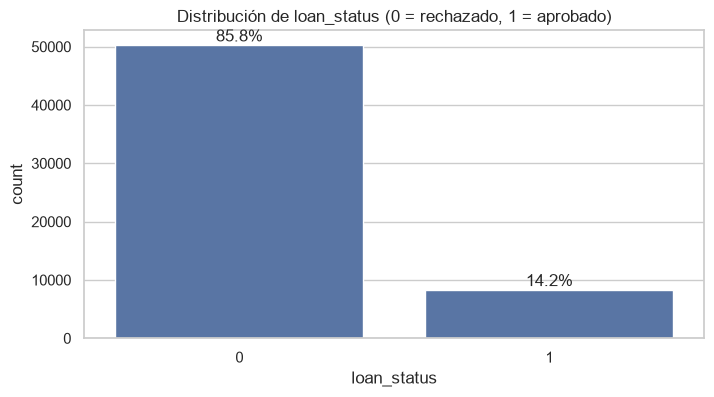

In [5]:
target_counts = train_raw[TARGET].value_counts(normalize=True)
print(target_counts)

ax = sns.countplot(x=TARGET, data=train_raw)
ax.set_title("Distribución de loan_status (0 = rechazado, 1 = aprobado)")
for p in ax.patches:
    ax.annotate(f"{p.get_height()/len(train_raw):.1%}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.show()


Bastante desbalanceado: solo ~14% de las solicitudes se aprueban.
Con esto en mente, voy a usar folds estratificados para la validación


## Variables numéricas

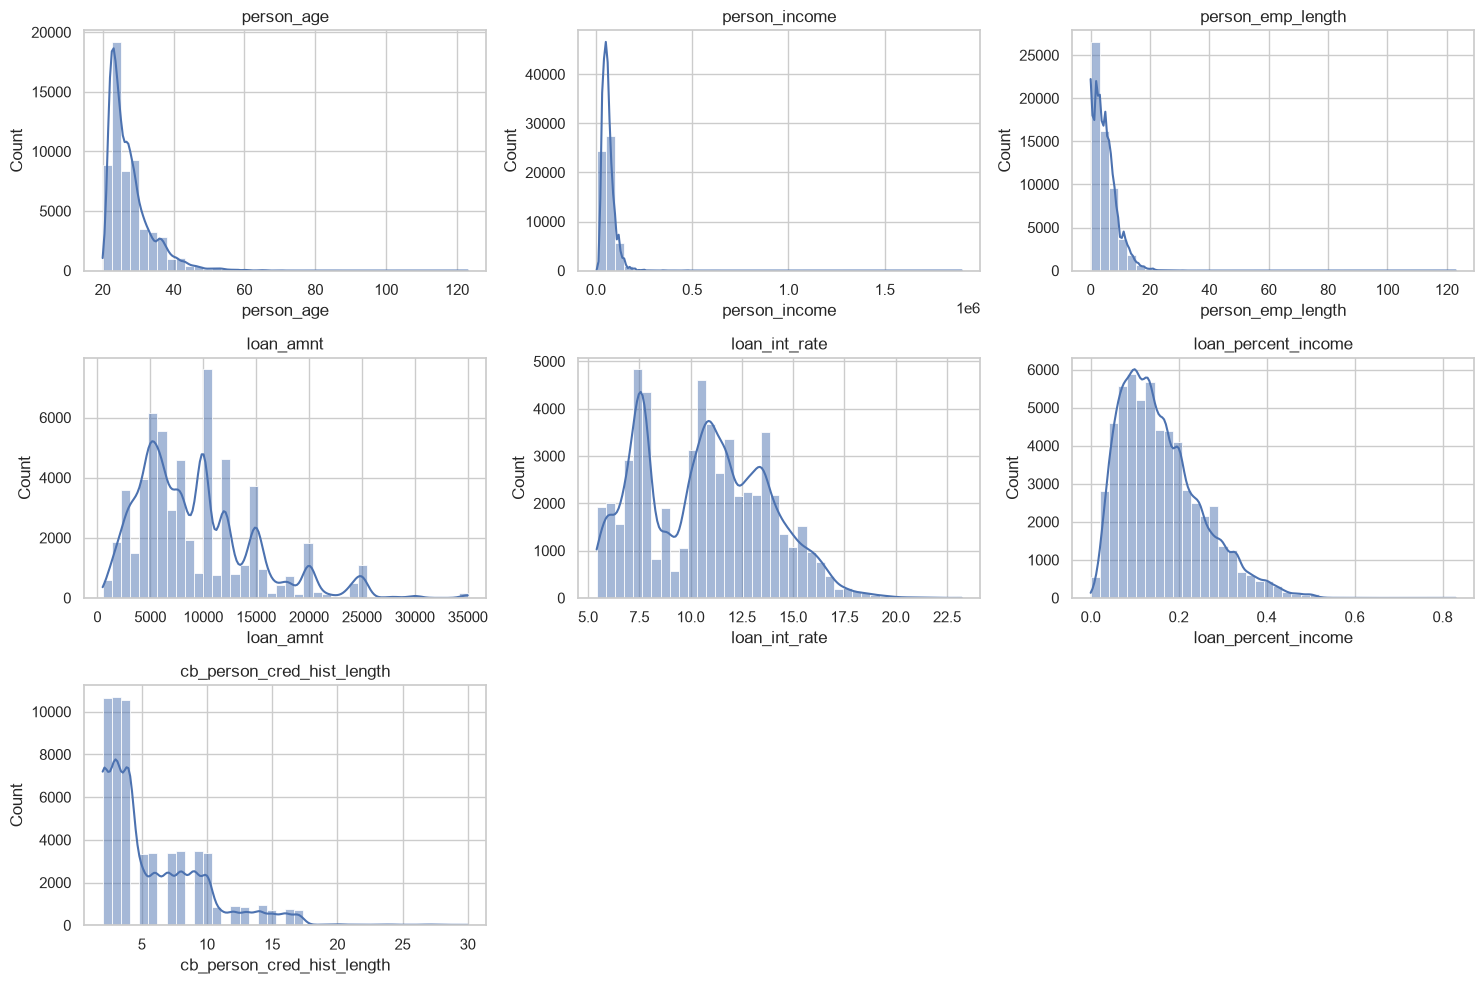

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flat, NUMERIC_COLS):
    sns.histplot(train_raw[col], bins=40, ax=ax, kde=True)
    ax.set_title(col)
for ax in axes.flat[len(NUMERIC_COLS):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()


In [7]:
train_raw[NUMERIC_COLS].describe().T


,count,mean,std,min,25%,50%,75%,max
person_age,58645.0,27.550857,6.033216,20.00,23.00,26.00,30.00,123.00
person_income,58645.0,64046.172871,37931.106978,4200.00,42000.00,58000.00,75600.00,1900000.00
person_emp_length,58645.0,4.701015,3.959784,0.00,2.00,4.00,7.00,123.00
loan_amnt,58645.0,9217.556518,5563.807384,500.00,5000.00,8000.00,12000.00,35000.00
loan_int_rate,58645.0,10.677874,3.034697,5.42,7.88,10.75,12.99,23.22
loan_percent_income,58645.0,0.159238,0.091692,0.00,0.09,0.14,0.21,0.83
cb_person_cred_hist_length,58645.0,5.813556,4.029196,2.00,3.00,4.00,8.00,30.00


Ahí están: `person_age` tiene gente de más de 120 años (obviamente un error de carga de
datos) y `person_emp_length` también se va por encima de 60 años de experiencia, lo cual
no tiene sentido para alguien que a la vez tiene 20-30 años. Los recorto en vez de tirar
esas filas — en `clean_outliers()` dentro de `src/features.py` — porque el test set también
tiene casos así y no me puedo dar el lujo de no predecirlos.


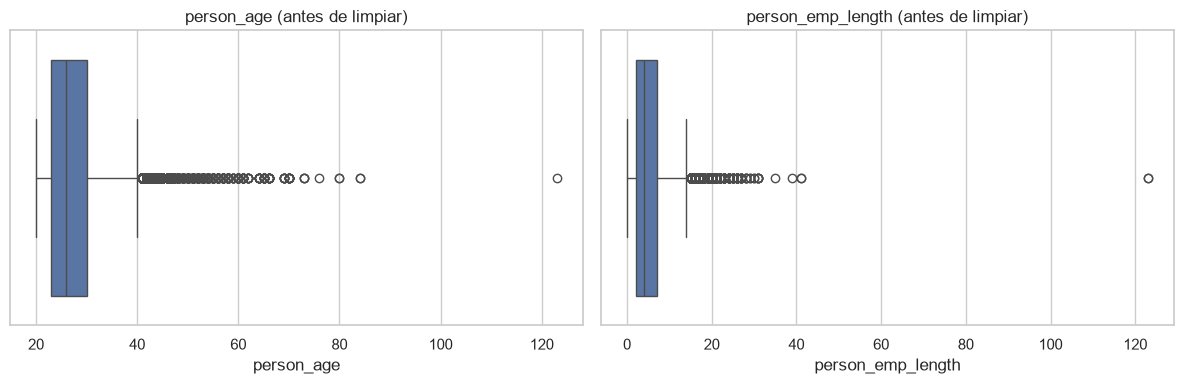

Registros con person_age > 80: 3
Registros con person_emp_length > 60: 2


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=train_raw["person_age"], ax=axes[0])
axes[0].set_title("person_age (antes de limpiar)")
sns.boxplot(x=train_raw["person_emp_length"], ax=axes[1])
axes[1].set_title("person_emp_length (antes de limpiar)")
plt.tight_layout()
plt.show()

print("Registros con person_age > 80:", (train_raw["person_age"] > 80).sum())
print("Registros con person_emp_length > 60:", (train_raw["person_emp_length"] > 60).sum())


## Categóricas contra el target

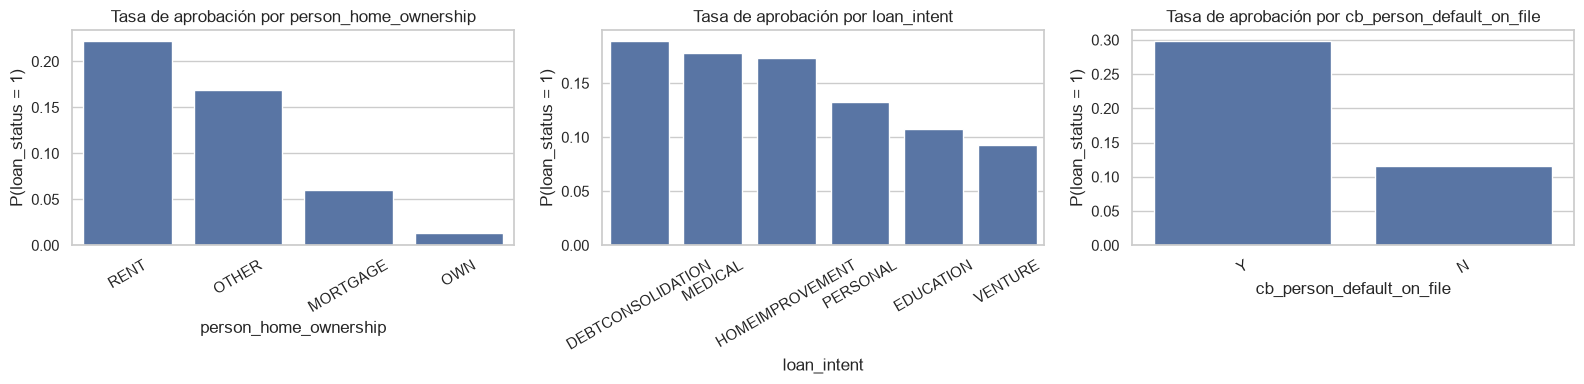

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, CATEGORICAL_COLS):
    rate = train_raw.groupby(col)[TARGET].mean().sort_values(ascending=False)
    sns.barplot(x=rate.index, y=rate.values, ax=ax)
    ax.set_title(f"Tasa de aprobación por {col}")
    ax.set_ylabel("P(loan_status = 1)")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


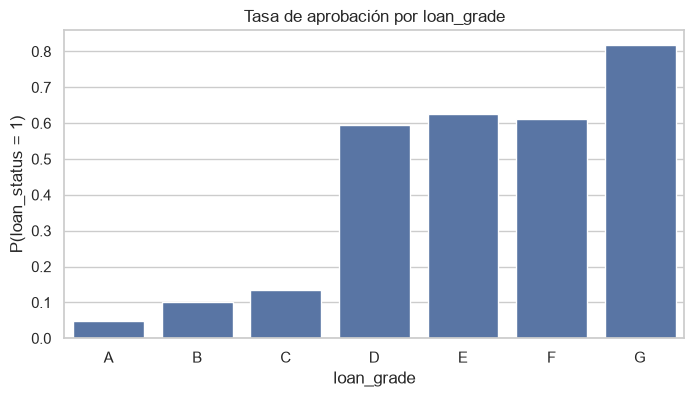

In [10]:
rate_grade = train_raw.groupby("loan_grade")[TARGET].mean().sort_index()
ax = sns.barplot(x=rate_grade.index, y=rate_grade.values)
ax.set_title("Tasa de aprobación por loan_grade")
ax.set_ylabel("P(loan_status = 1)")
plt.show()


Esto es lo más claro que vi en todo el EDA: `loan_grade` sube de A a G prácticamente en
línea recta con la probabilidad de que el target sea 1. Tiene todo el sentido (la letra
ya es una medida de riesgo), así que en vez de tratarla como una categórica cualquiera la
paso a ordinal (A=0 ... G=6) para que el modelo no pierda ese orden.


## Correlaciones entre las numéricas

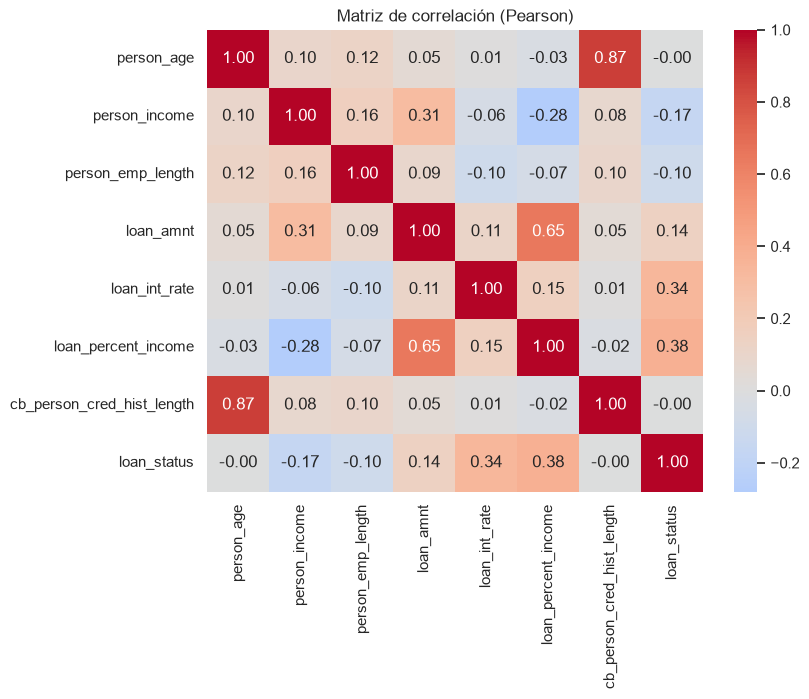

In [11]:
corr = train_raw[NUMERIC_COLS + [TARGET]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación (Pearson)")
plt.show()


`loan_percent_income` y `loan_int_rate` son las que más se mueven con el target. Tiene
lógica: cuanto más pesa el préstamo sobre lo que ganas y más alta la tasa que te ponen
(que ya de por sí refleja el riesgo que te asignaron), más probable que quede como 1.


## Features nuevas

In [12]:
train = build_model_frame(train_raw)
test = build_model_frame(test_raw)

cols = feature_columns()
print(f"Total de features usadas por el modelo: {len(cols)}")
cols


Total de features usadas por el modelo: 17


['person_age',
 'person_income',
 'person_emp_length',
 'loan_amnt',
 'loan_int_rate',
 'loan_percent_income',
 'cb_person_cred_hist_length',
 'person_home_ownership',
 'loan_intent',
 'cb_person_default_on_file',
 'loan_grade_ordinal',
 'income_to_loan_ratio',
 'credit_history_ratio',
 'age_emp_ratio',
 'income_per_year_employed',
 'log_person_income',
 'log_loan_amnt']

In [13]:
train[cols + [TARGET]].head()


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership,loan_intent,cb_person_default_on_file,loan_grade_ordinal,income_to_loan_ratio,credit_history_ratio,age_emp_ratio,income_per_year_employed,log_person_income,log_loan_amnt,loan_status
0,37,35000,0.0,6000,11.49,0.17,14,RENT,EDUCATION,N,1,5.832361,0.368421,0.000000,35000.000000,10.463132,8.699681,0
1,22,56000,6.0,4000,13.35,0.07,2,OWN,MEDICAL,N,2,13.996501,0.086957,0.260870,8000.000000,10.933125,8.294300,0
2,29,28800,8.0,6000,8.90,0.21,10,OWN,PERSONAL,N,0,4.799200,0.333333,0.266667,3200.000000,10.268165,8.699681,0
3,30,70000,14.0,12000,11.11,0.17,5,RENT,VENTURE,N,1,5.832847,0.161290,0.451613,4666.666667,11.156265,9.392745,0
4,22,60000,2.0,6000,6.92,0.10,3,RENT,MEDICAL,N,0,9.998334,0.130435,0.086957,20000.000000,11.002117,8.699681,0


Además de lo que ya venía en el dataset, agregué estas (todo vive en `src/features.py`,
para no repetir la lógica entre el notebook y el script de entrenamiento):

- `loan_grade_ordinal`: la letra A-G pasada a número 0-6.
- `income_to_loan_ratio`: ingreso sobre monto del préstamo, como proxy de capacidad de pago.
- `credit_history_ratio`: años de historial crediticio sobre edad — cuánta "vida crediticia"
  relativa tiene la persona.
- `age_emp_ratio`: parecido pero con años de empleo.
- `income_per_year_employed`: ingreso normalizado por experiencia laboral.
- `log_person_income` y `log_loan_amnt`: log1p, porque ambas tienen una cola bien larga a
  la derecha y así ayudo un poco a los modelos lineales.


## Modelos

Para validar uso Stratified K-Fold con 5 folds, manteniendo la proporción de clases en
cada uno. Voy a probar dos cosas:

1. Una regresión logística de referencia, para tener un piso con el que comparar.
2. LightGBM, que suele ir bien en este tipo de datos tabulares y maneja las categóricas
   sin que yo tenga que hacer one-hot a mano.


In [14]:
X = train[cols].copy()
y = train[TARGET].values
X_test = test[cols].copy()

for c in CATEGORICAL_COLS:
    X[c] = X[c].astype("category")
    X_test[c] = X_test[c].astype("category")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


### Regresión logística (referencia)

In [15]:
numeric_for_lr = [c for c in cols if c not in CATEGORICAL_COLS]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_for_lr),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_COLS),
])

lr_oof = np.zeros(len(X))
for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
    pipe = Pipeline([
        ("prep", preprocessor),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ])
    pipe.fit(X.iloc[tr_idx], y[tr_idx])
    lr_oof[va_idx] = pipe.predict_proba(X.iloc[va_idx])[:, 1]

lr_auc = roc_auc_score(y, lr_oof)
print(f"Regresión Logística — AUC out-of-fold: {lr_auc:.5f}")


Regresión Logística — AUC out-of-fold: 0.89868


### LightGBM

In [16]:
lgbm_oof = np.zeros(len(X))
lgbm_test_preds = np.zeros(len(X_test))
fold_aucs = []
models = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
    model = LGBMClassifier(
        n_estimators=2000,
        learning_rate=0.03,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=RANDOM_STATE,
        verbosity=-1,
    )
    model.fit(
        X.iloc[tr_idx], y[tr_idx],
        eval_X=X.iloc[va_idx], eval_y=y[va_idx],
        categorical_feature=CATEGORICAL_COLS,
        callbacks=[early_stopping(100, verbose=False), log_evaluation(0)],
    )
    val_pred = model.predict_proba(X.iloc[va_idx])[:, 1]
    lgbm_oof[va_idx] = val_pred
    fold_auc = roc_auc_score(y[va_idx], val_pred)
    fold_aucs.append(fold_auc)
    print(f"Fold {fold}/5 — AUC: {fold_auc:.5f} — mejores iteraciones: {model.best_iteration_}")

    lgbm_test_preds += model.predict_proba(X_test)[:, 1] / skf.n_splits
    models.append(model)

lgbm_auc = roc_auc_score(y, lgbm_oof)
print(f"\nLightGBM — AUC promedio por fold: {np.mean(fold_aucs):.5f} (+/- {np.std(fold_aucs):.5f})")
print(f"LightGBM — AUC out-of-fold: {lgbm_auc:.5f}")


Fold 1/5 — AUC: 0.95095 — mejores iteraciones: 374


Fold 2/5 — AUC: 0.96119 — mejores iteraciones: 350


Fold 3/5 — AUC: 0.95482 — mejores iteraciones: 326


Fold 4/5 — AUC: 0.96020 — mejores iteraciones: 336


Fold 5/5 — AUC: 0.95715 — mejores iteraciones: 303

LightGBM — AUC promedio por fold: 0.95686 (+/- 0.00372)
LightGBM — AUC out-of-fold: 0.95672


### ¿Cuál gana?

In [17]:
results = pd.DataFrame({
    "modelo": ["Regresión Logística (baseline)", "LightGBM (5-fold CV)"],
    "AUC_oof": [lr_auc, lgbm_auc],
}).sort_values("AUC_oof", ascending=False).reset_index(drop=True)
results


,modelo,AUC_oof
0,LightGBM (5-fold CV),0.956724
1,Regresión Logística (baseline),0.898684


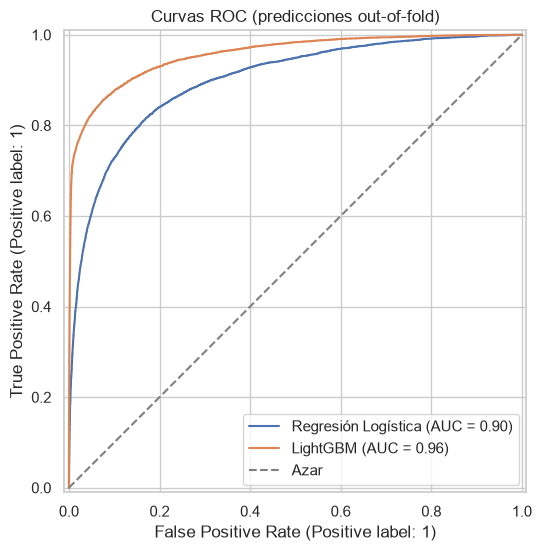

In [18]:
fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(y, lr_oof, name="Regresión Logística", ax=ax)
RocCurveDisplay.from_predictions(y, lgbm_oof, name="LightGBM", ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
ax.set_title("Curvas ROC (predicciones out-of-fold)")
ax.legend()
plt.show()


LightGBM le saca bastante ventaja a la regresión logística (0.9567 vs 0.8987 de AUC), lo
cual tampoco me sorprende tanto: hay interacciones entre `loan_grade`, `loan_int_rate` y
`loan_percent_income` que un modelo lineal simplemente no puede capturar. Me quedo con
LightGBM como modelo final.


## ¿Qué variables pesan más?

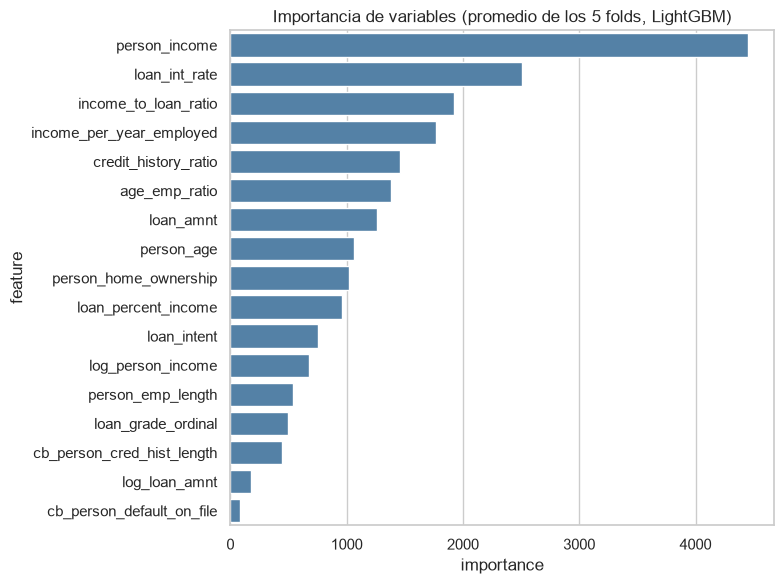

,feature,importance
1,person_income,4452.4
4,loan_int_rate,2504.4
11,income_to_loan_ratio,1920.8
14,income_per_year_employed,1767.8
12,credit_history_ratio,1457.2
13,age_emp_ratio,1378.8
3,loan_amnt,1257.2
0,person_age,1062.6
7,person_home_ownership,1016.0
5,loan_percent_income,956.0


In [19]:
importances = pd.DataFrame({
    "feature": cols,
    "importance": np.mean([m.feature_importances_ for m in models], axis=0),
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=importances, x="importance", y="feature", color="steelblue")
plt.title("Importancia de variables (promedio de los 5 folds, LightGBM)")
plt.tight_layout()
plt.show()

importances


## Generando el submission

Uso el promedio de los 5 modelos de la validación cruzada para predecir sobre test, en
vez de reentrenar uno solo con el 100% del train — en la práctica ese promedio (un
mini-ensamble gratis) suele generalizar un poco mejor.


In [20]:
submission = sample_submission.copy()
submission[TARGET] = lgbm_test_preds

submission.to_csv("../submissions/submission.csv", index=False)
submission.head()


,id,loan_status
0,58645,0.988244
1,58646,0.012354
2,58647,0.683340
3,58648,0.011912
4,58649,0.081868


In [21]:
print("Filas en submission:", len(submission))
print("Rango de probabilidades predichas:", submission[TARGET].min(), "-", submission[TARGET].max())


Filas en submission: 39098
Rango de probabilidades predichas: 0.0004356361159518329 - 0.9983571562155757


## Cierre

En resumen: los datos venían bastante limpios salvo por un par de outliers claros en edad
y años de empleo, que corregí acotándolos. `loan_grade`, `loan_percent_income` y
`loan_int_rate` terminaron siendo, como esperaba por la intuición del dominio, las
variables que más pesan a la hora de predecir si una solicitud queda marcada como riesgosa.

LightGBM (AUC 0.9567 out-of-fold)
